In [7]:
import pandas as pd

In [8]:
from sklearn.datasets import fetch_california_housing

In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [10]:
df=fetch_california_housing()

In [11]:
df

{'data': array([[   8.3252    ,   41.        ,    6.98412698, ...,    2.55555556,
           37.88      , -122.23      ],
        [   8.3014    ,   21.        ,    6.23813708, ...,    2.10984183,
           37.86      , -122.22      ],
        [   7.2574    ,   52.        ,    8.28813559, ...,    2.80225989,
           37.85      , -122.24      ],
        ...,
        [   1.7       ,   17.        ,    5.20554273, ...,    2.3256351 ,
           39.43      , -121.22      ],
        [   1.8672    ,   18.        ,    5.32951289, ...,    2.12320917,
           39.43      , -121.32      ],
        [   2.3886    ,   16.        ,    5.25471698, ...,    2.61698113,
           39.37      , -121.24      ]]),
 'target': array([4.526, 3.585, 3.521, ..., 0.923, 0.847, 0.894]),
 'frame': None,
 'target_names': ['MedHouseVal'],
 'feature_names': ['MedInc',
  'HouseAge',
  'AveRooms',
  'AveBedrms',
  'Population',
  'AveOccup',
  'Latitude',
  'Longitude'],
 'DESCR': '.. _california_housing_dataset:\n

In [12]:
dataset = pd.DataFrame(df.data)

In [13]:
dataset.head()

,0,1,2,3,4,5,6,7
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25


In [14]:
## Independent features and dependent features

X= dataset
y=df.target

In [15]:
y

array([4.526, 3.585, 3.521, ..., 0.923, 0.847, 0.894])

In [16]:
## train test split 
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=42)

In [17]:
## standardizing the dataset
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

In [18]:
X_train=scaler.fit_transform(X_train)

In [19]:
X_test=scaler.transform(X_test)

In [20]:
from sklearn.linear_model import LinearRegression
##cross validation
from sklearn.model_selection import cross_val_score

In [21]:
regression=LinearRegression()
regression.fit(X_train,y_train)

LinearRegression()

In [22]:
mse=cross_val_score(regression,X_train,y_train,scoring='neg_mean_squared_error',cv=10)

In [23]:
np.mean(mse)

np.float64(-0.5257104326777001)

In [24]:
##prediction 
reg_pred=regression.predict(X_test)

In [25]:
reg_pred

array([0.72604907, 1.76743383, 2.71092161, ..., 2.07465531, 1.57371395,
       1.82744133])

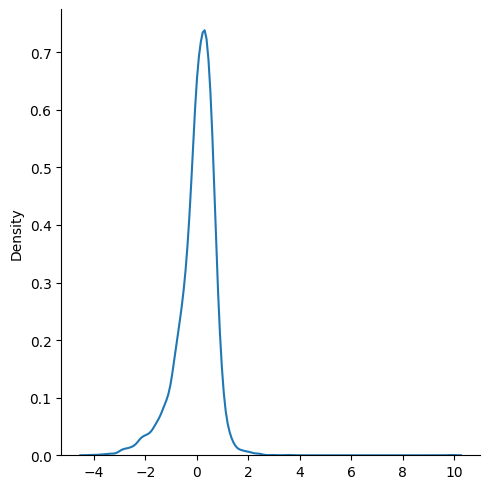

In [26]:
import seaborn as sns
sns.displot(reg_pred-y_test,kind='kde')

In [27]:
from sklearn.metrics import r2_score

In [28]:
score=r2_score(reg_pred,y_test)

In [29]:
score

0.3451339380943895

## Ridge And Lasso Regression

In [30]:
from sklearn.linear_model import Ridge
from sklearn.model_selection import GridSearchCV

In [31]:
ridge_regressor = Ridge()

In [32]:
ridge_regressor

Ridge()

In [33]:
parameter = {'alpha':[1,2,5,10,20,30,40,50,60,70,80,90]}

ridgecv = GridSearchCV(ridge_regressor,parameter,scoring='neg_mean_squared_error',cv=5)

ridgecv.fit(X_train,y_train)


GridSearchCV(cv=5, estimator=Ridge(),
             param_grid={'alpha': [1, 2, 5, 10, 20, 30, 40, 50, 60, 70, 80,
                                   90]},
             scoring='neg_mean_squared_error')

In [34]:
print(ridgecv.best_params_)

{'alpha': 5}


In [ ]:
print(ridgecv.best_score_)

-0.5268179966861514


In [39]:
ridge_pred = ridgecv.predict(X_test)

In [41]:
ridge_pred

array([0.72799408, 1.76647219, 2.70889662, ..., 2.07364426, 1.57452579,
       1.82666041])

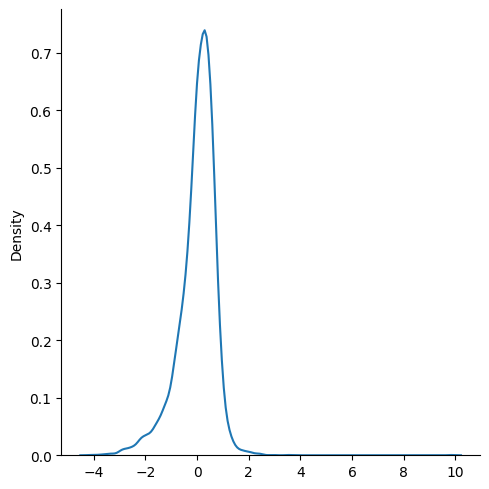

In [42]:
import seaborn as sns
sns.displot(ridge_pred-y_test,kind='kde')

## Lasso Regression


In [43]:
from sklearn.linear_model import Lasso

lasso =Lasso()

In [44]:
parameter = {'alpha':[1,2,5,10,20,30,40,50,60,70,80,90]}

lassocv = GridSearchCV(lasso,parameter,scoring='neg_mean_squared_error',cv=5)

lassocv.fit(X_train,y_train)

GridSearchCV(cv=5, estimator=Lasso(),
             param_grid={'alpha': [1, 2, 5, 10, 20, 30, 40, 50, 60, 70, 80,
                                   90]},
             scoring='neg_mean_squared_error')

In [45]:
print(lassocv.best_params_)
print(lassocv.best_score_)

{'alpha': 1}
-1.3400019579636542


In [46]:
lasso_pred = lassocv.predict(X_test)

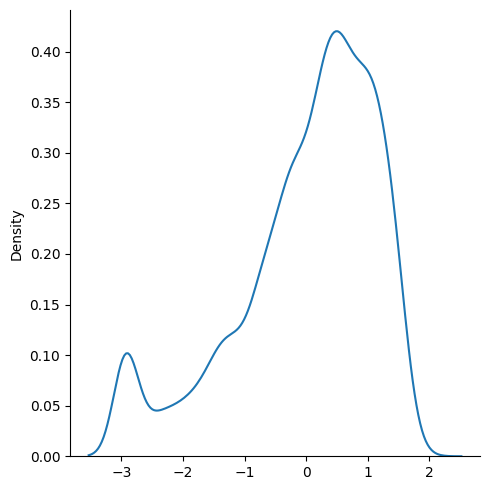

In [47]:
import seaborn as sns
sns.displot(lasso_pred-y_test,kind='kde')